# Practice Assignment: Analyzing Wildfire Activities in Australia

In this lab, I will analyze historical wildfire activity in Australia using Python visualization libraries.

I will use:
- Pandas for data preparation
- Matplotlib and Seaborn for charts
- Folium for geographic visualization

In [1]:
# Install Folium if needed
!pip install folium

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline

## Load the Wildfire Dataset

The dataset contains historical wildfire activity in Australia, including fire area, brightness, confidence, radiative power, and regional information.

In [3]:
# Load wildfire dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"

df = pd.read_csv(url)

# Display first rows
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [4]:
# Check dataset shape
df.shape

(26406, 10)

In [5]:
# Check column names
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='object')

In [6]:
# Check data types
df.dtypes

,0
Region,object
Date,object
Estimated_fire_area,float64
Mean_estimated_fire_brightness,float64
Mean_estimated_fire_radiative_power,float64
Mean_confidence,float64
Std_confidence,float64
Var_confidence,float64
Count,int64
Replaced,object


## Prepare Date Columns

The `Date` column needs to be converted into datetime format so I can extract the year and month for time-based analysis.

In [7]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Extract year and month
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Verify new columns
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced,Year,Month
0,NSW,2005-01-04,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R,2005,1
1,NSW,2005-01-05,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R,2005,1
2,NSW,2005-01-06,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R,2005,1
3,NSW,2005-01-07,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R,2005,1
4,NSW,2005-01-08,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R,2005,1


## Task 1: Average Estimated Fire Area Over Time

This line chart shows how the average estimated fire area changes over time.

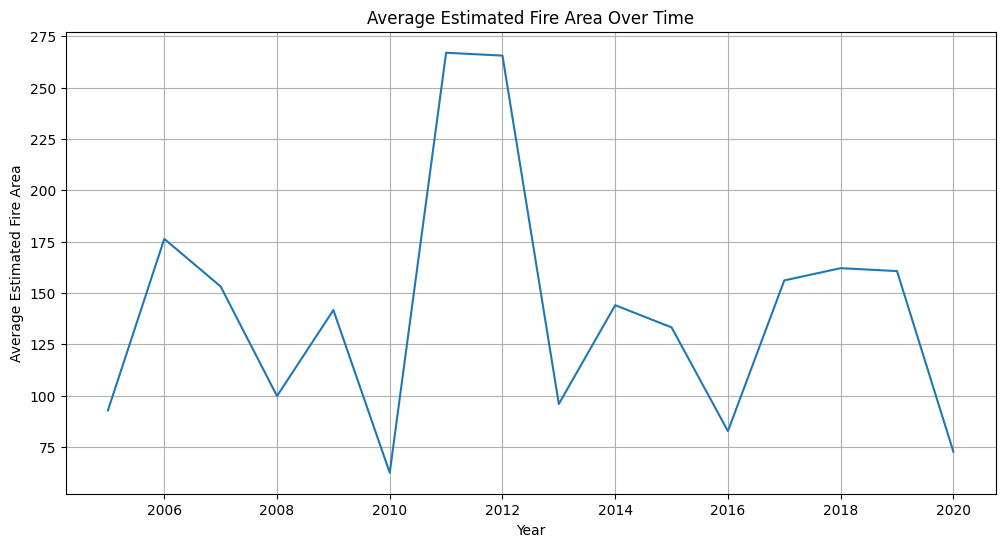

In [8]:
# Calculate average estimated fire area by year
fire_area_year = df.groupby("Year")["Estimated_fire_area"].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(fire_area_year["Year"], fire_area_year["Estimated_fire_area"])

plt.title("Average Estimated Fire Area Over Time")
plt.xlabel("Year")
plt.ylabel("Average Estimated Fire Area")
plt.grid(True)
plt.show()

## Task 2: Estimated Fire Area by Year and Month

This chart narrows the view by showing estimated fire area grouped by both year and month.

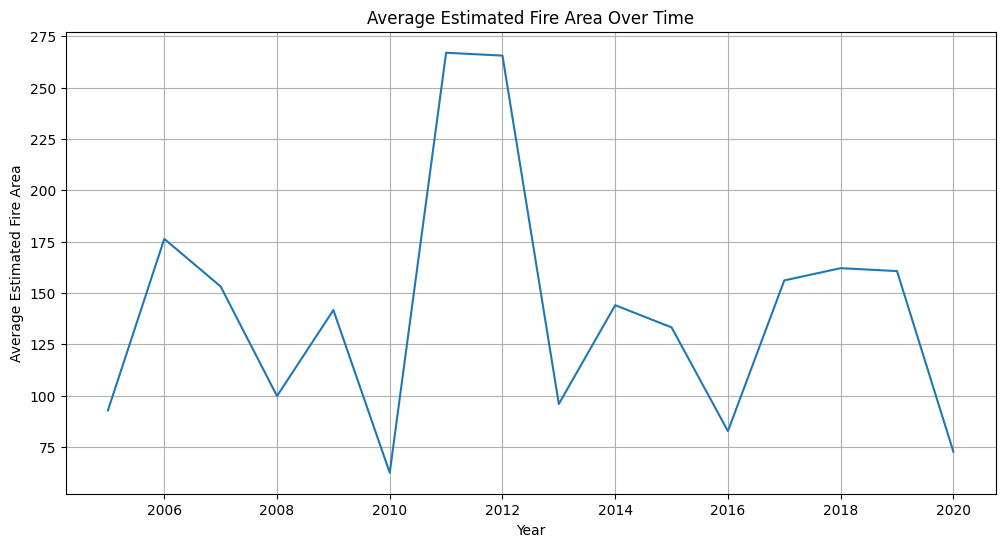

In [9]:
# Calculate average estimated fire area by year
fire_area_year = df.groupby("Year")["Estimated_fire_area"].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(fire_area_year["Year"], fire_area_year["Estimated_fire_area"])

plt.title("Average Estimated Fire Area Over Time")
plt.xlabel("Year")
plt.ylabel("Average Estimated Fire Area")
plt.grid(True)
plt.show()

## Task 2: Estimated Fire Area by Year and Month

This chart narrows the view by showing estimated fire area grouped by both year and month.

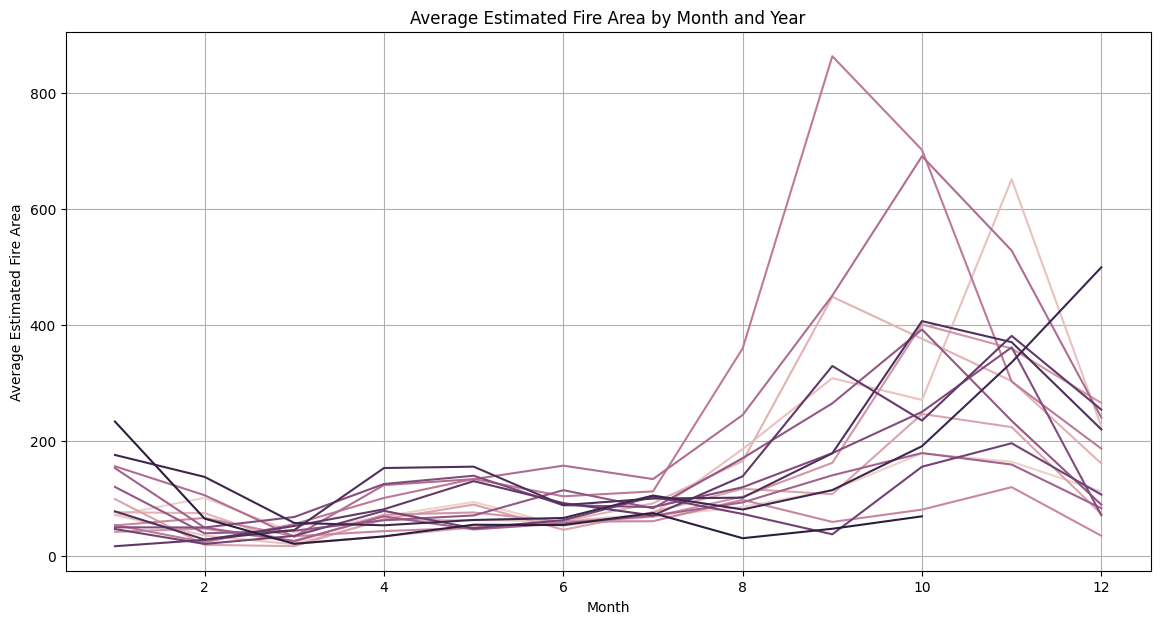

In [10]:
# Group by year and month
fire_area_month = df.groupby(["Year", "Month"])["Estimated_fire_area"].mean().reset_index()

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=fire_area_month,
    x="Month",
    y="Estimated_fire_area",
    hue="Year",
    legend=False
)

plt.title("Average Estimated Fire Area by Month and Year")
plt.xlabel("Month")
plt.ylabel("Average Estimated Fire Area")
plt.grid(True)
plt.show()

## Task 3: Distribution of Mean Estimated Fire Brightness by Region

This bar chart shows how estimated fire brightness varies across Australian regions.

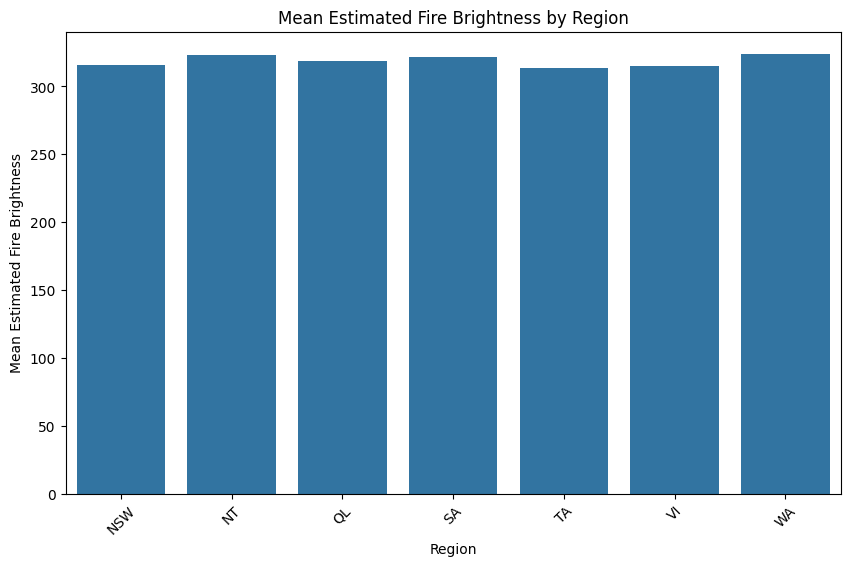

In [11]:
# Average brightness by region
brightness_region = df.groupby("Region")["Mean_estimated_fire_brightness"].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=brightness_region,
    x="Region",
    y="Mean_estimated_fire_brightness"
)

plt.title("Mean Estimated Fire Brightness by Region")
plt.xlabel("Region")
plt.ylabel("Mean Estimated Fire Brightness")
plt.xticks(rotation=45)
plt.show()

## Task 4: Percentage of Presumed Vegetation Fires by Region

This pie chart shows the proportion of vegetation fire pixels by region.

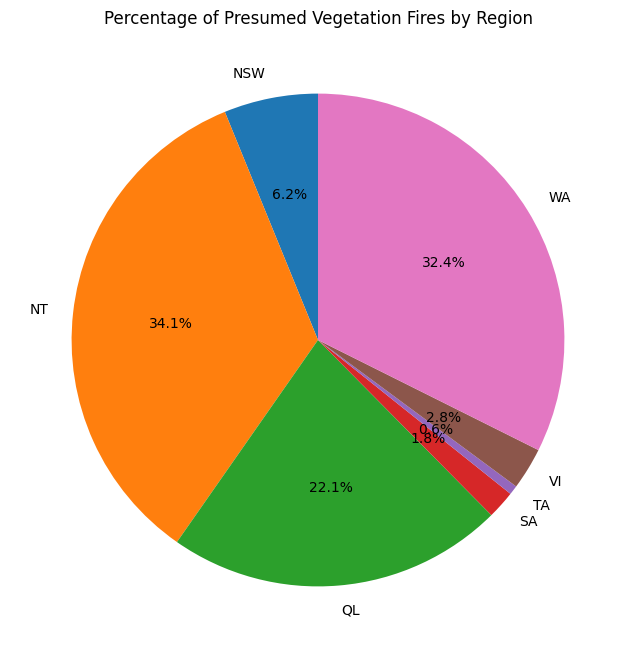

In [12]:
# Count pixels by region
region_counts = df.groupby("Region")["Count"].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Presumed Vegetation Fires by Region")
plt.show()

## Task 5: Improve Pie Chart Readability

The pie chart can overlap, so I will adjust the figure size and label spacing.

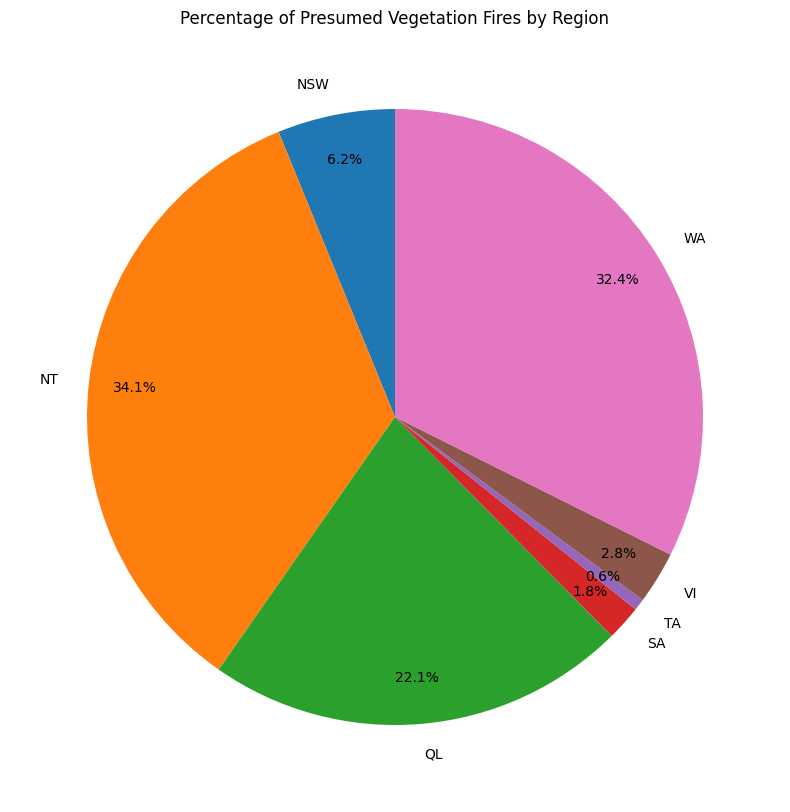

In [13]:
plt.figure(figsize=(10, 10))

plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)

plt.title("Percentage of Presumed Vegetation Fires by Region")
plt.show()

## Task 6: Histogram of Mean Estimated Fire Brightness

This histogram shows the distribution of mean estimated fire brightness values.

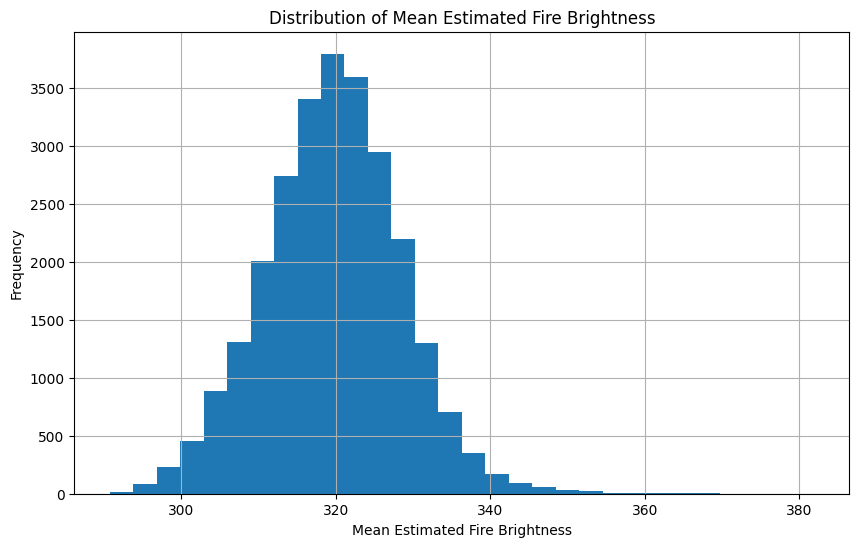

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(df["Mean_estimated_fire_brightness"], bins=30)

plt.title("Distribution of Mean Estimated Fire Brightness")
plt.xlabel("Mean Estimated Fire Brightness")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Task 7: Fire Brightness Distribution by Region

This Seaborn histogram compares estimated fire brightness across regions.

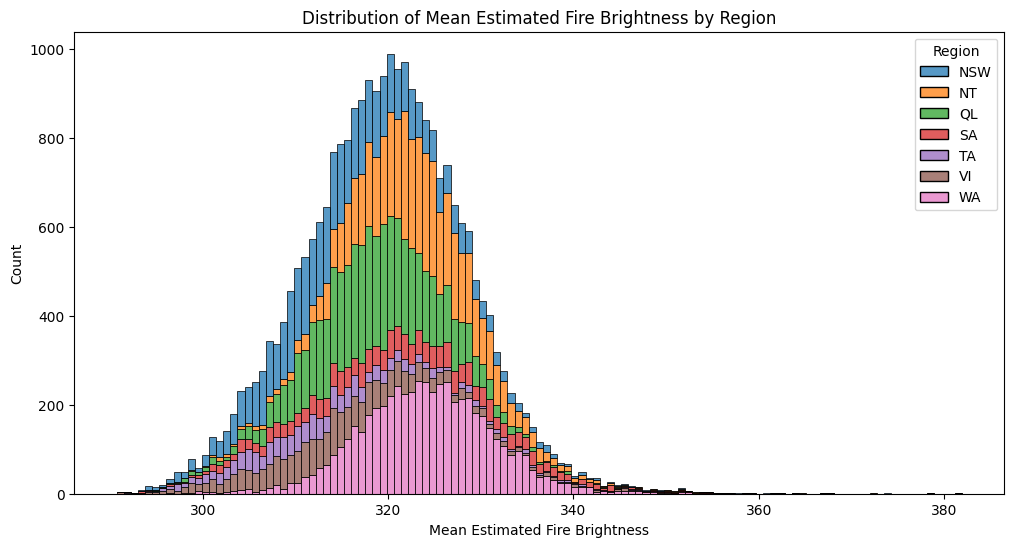

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Mean_estimated_fire_brightness",
    hue="Region",
    multiple="stack"
)

plt.title("Distribution of Mean Estimated Fire Brightness by Region")
plt.xlabel("Mean Estimated Fire Brightness")
plt.ylabel("Count")
plt.show()

## Task 8: Correlation Between Radiative Power and Confidence

This scatter plot helps examine whether radiative power and confidence level are related.

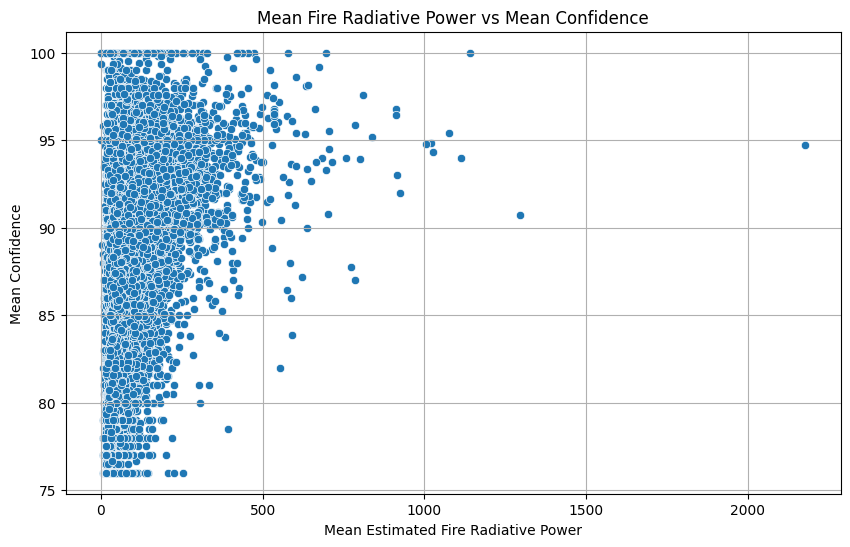

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Mean_estimated_fire_radiative_power",
    y="Mean_confidence"
)

plt.title("Mean Fire Radiative Power vs Mean Confidence")
plt.xlabel("Mean Estimated Fire Radiative Power")
plt.ylabel("Mean Confidence")
plt.grid(True)
plt.show()

## Task 9: Map Australian Regions Using Folium

This map marks Australian regions using latitude and longitude values.

In [17]:
# Create region coordinate data
region_data = pd.DataFrame({
    "Region": ["NSW", "NT", "QL", "SA", "TA", "VI", "WA"],
    "Lat": [-31.2532, -19.4914, -20.9176, -30.0002, -42.0409, -37.4713, -27.6728],
    "Lon": [146.9211, 132.5510, 142.7028, 136.2092, 146.8087, 144.7852, 121.6283]
})

# Create map centered on Australia
aus_map = folium.Map(location=[-25.2744, 133.7751], zoom_start=4)

# Add markers
for _, row in region_data.iterrows():
    folium.Marker(
        location=[row["Lat"], row["Lon"]],
        popup=row["Region"]
    ).add_to(aus_map)

aus_map

## Conclusion

In this lab, I analyzed wildfire activity in Australia using multiple visualization techniques.

I practiced:
- Loading and preparing wildfire data
- Extracting year and month from dates
- Creating line charts, bar charts, pie charts, histograms, and scatter plots
- Comparing wildfire activity across regions
- Mapping geographic regions using Folium

This lab helped me understand how visualization can reveal patterns in environmental data over time and across locations.